In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [3]:
cell_num = 25#MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 250000 # sampling rate
lfp_fs = 25500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell   
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 

## Step 0: Get loaded data 

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c25_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c25_patch.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

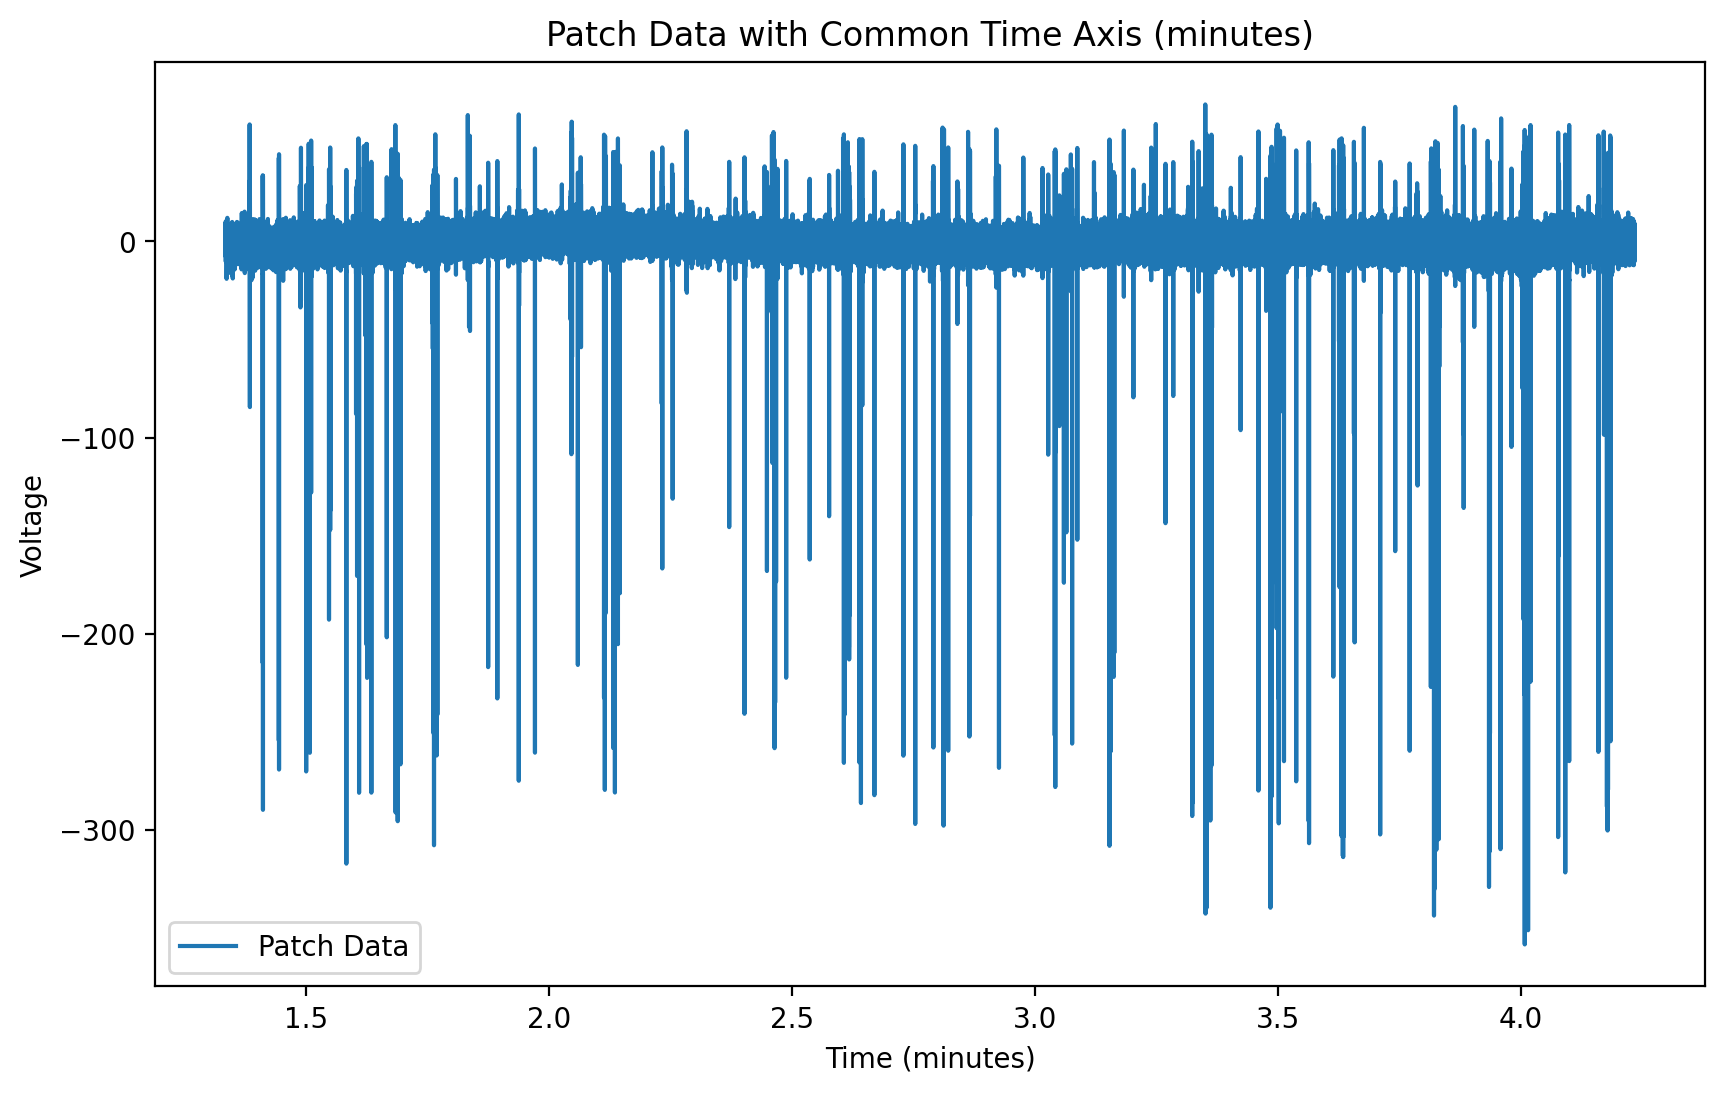

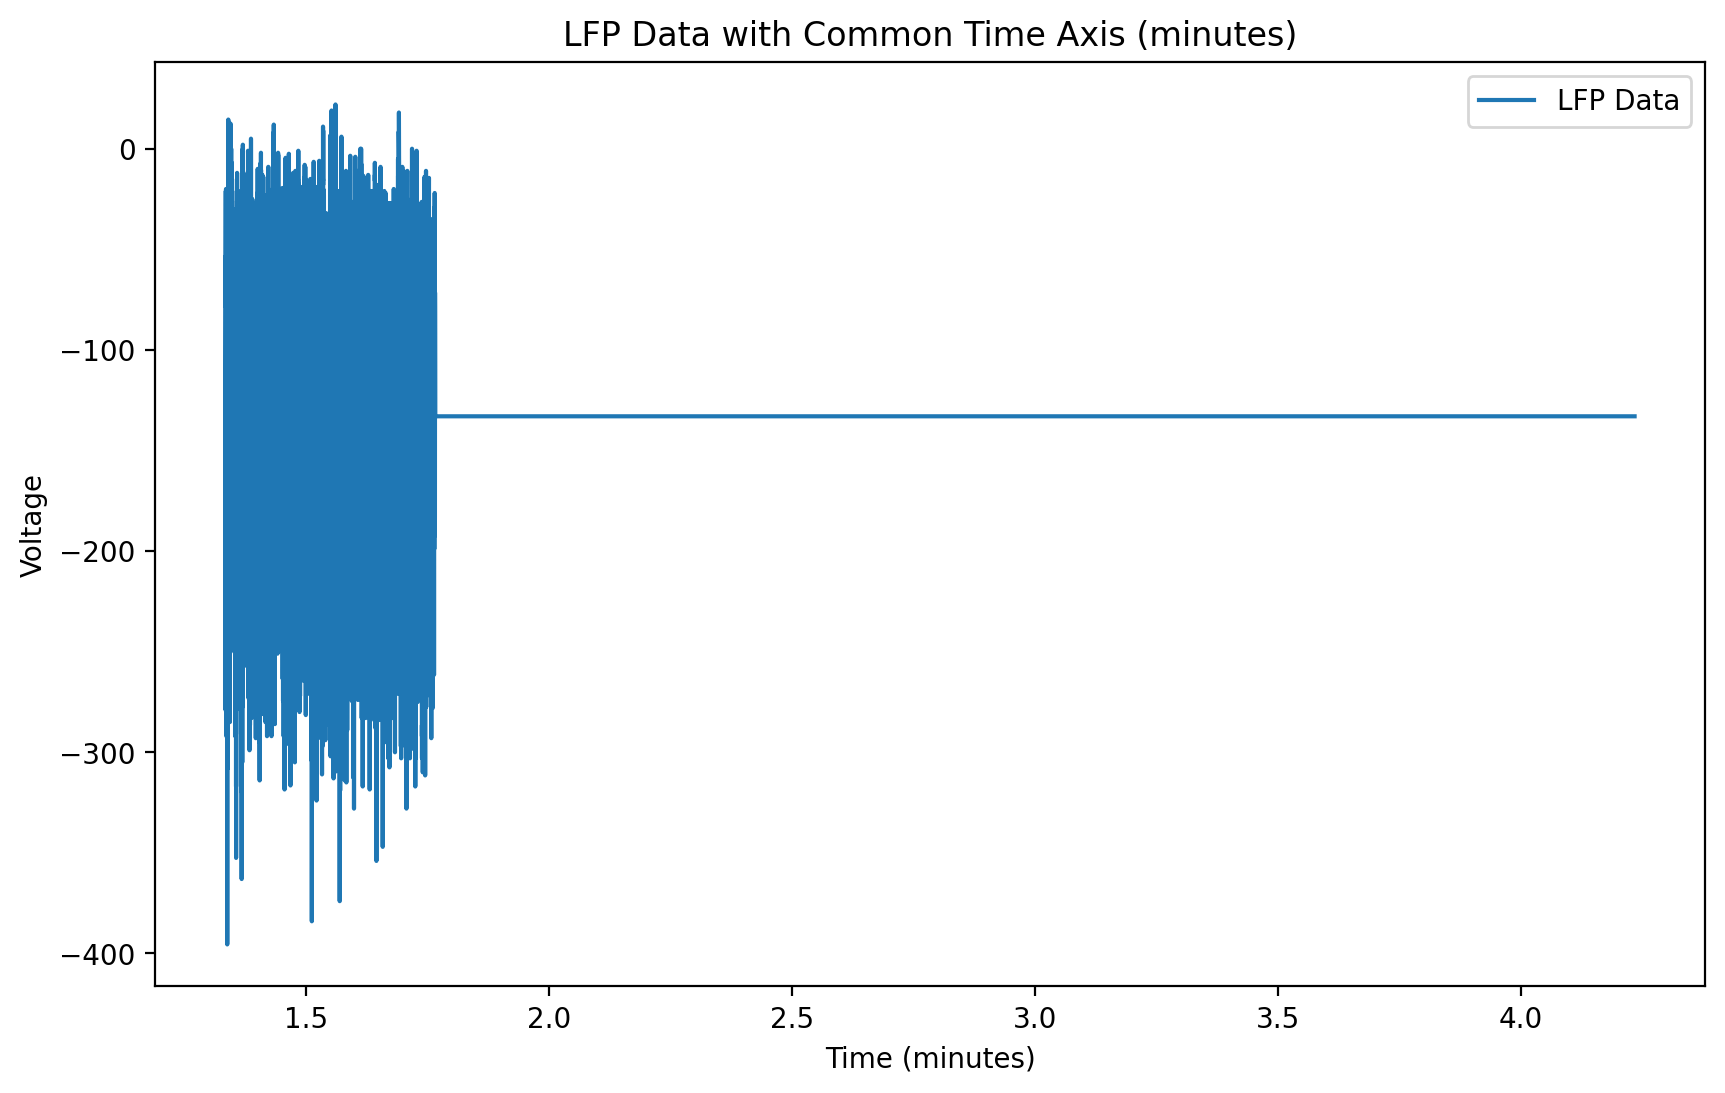

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 125.25252525 to 255.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 254000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

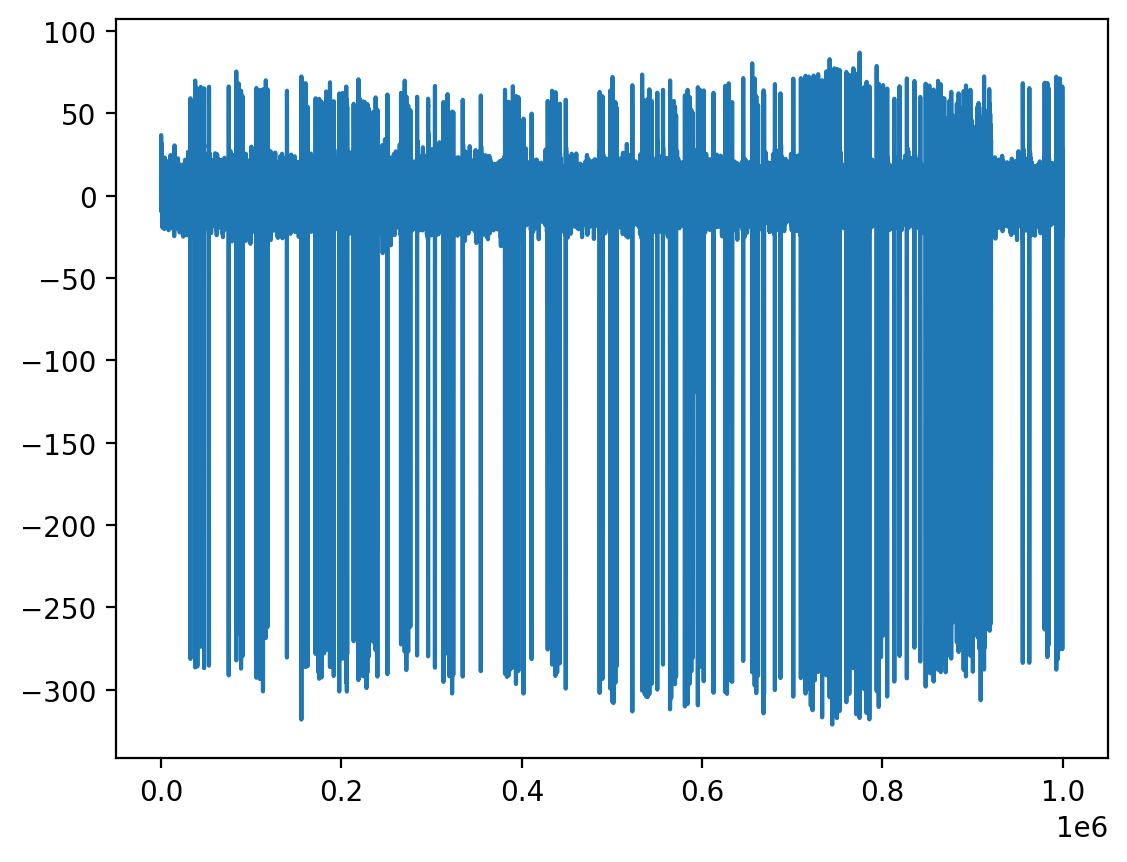

In [7]:
plt.plot(patch_filt[:1000000] )

In [8]:



#threshold in mVs
sp = Spike(thresh_amp=96, window_length=(5., 5.), smooth_frac=.01)

In [9]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=True)

Spike:   0%|          | 0/4890 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/numpy-1.24.1-py3.9-macosx-10.9-x86_64.egg/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/numpy-1.24.1-py3.9-macosx-10.9-x86_64.egg/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


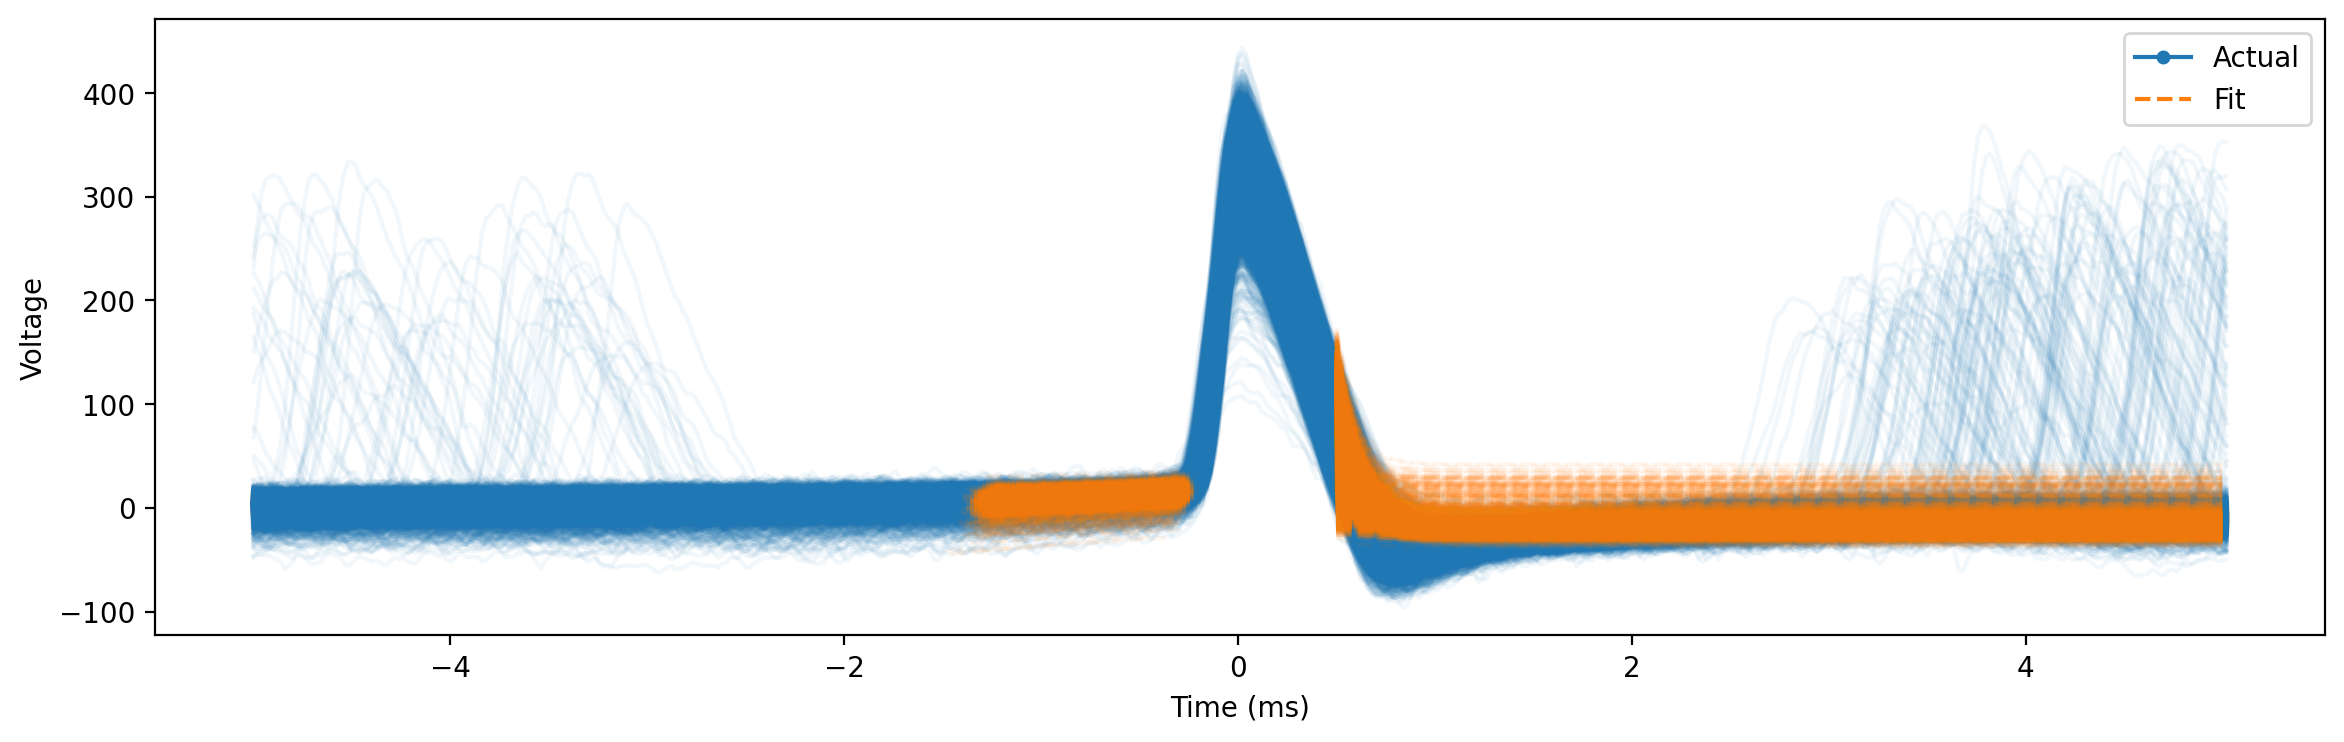

In [10]:
sp.plot()

### Filter spikes 

In [11]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [12]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [13]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
4,5.339702,0.24,11.083944,282.080292,0.34,100.083379,0.000005,-11.844059,2.035142,47733,9.542041e+02,0
28,8.355144,0.24,16.078914,300.450517,0.34,104.928247,0.000009,-13.335006,1.866670,197594,3.949993e+03,1
29,5.820529,0.24,7.714819,278.730264,0.36,97.651217,0.000045,-12.320808,1.979978,201274,4.023558e+03,2
45,8.137654,0.24,10.402733,282.025356,0.32,108.023199,0.000017,-16.620654,1.613211,272002,5.437442e+03,3
52,7.255401,0.24,16.356073,277.622851,0.32,95.527065,0.000022,-17.887700,1.633665,317683,6.350626e+03,4
...,...,...,...,...,...,...,...,...,...,...,...,...
4877,5.857148,0.36,13.602138,238.235210,0.54,28.708466,9.582535,-11.783276,1.331827,53874323,1.076972e+06,2746
4879,4.093794,0.34,15.098414,231.180390,0.52,31.077915,9.754634,-22.804262,1.530248,53878359,1.077053e+06,2747
4880,5.954785,0.34,23.033010,239.707314,0.54,27.432366,10.000000,-7.741266,3.212635,53880055,1.077086e+06,2748
4883,4.138010,0.34,11.843785,236.465663,0.52,27.505821,10.000000,-15.762146,1.481235,53969332,1.078871e+06,2749


### Get spike times


In [14]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 2: Cluster spike groups (if any)

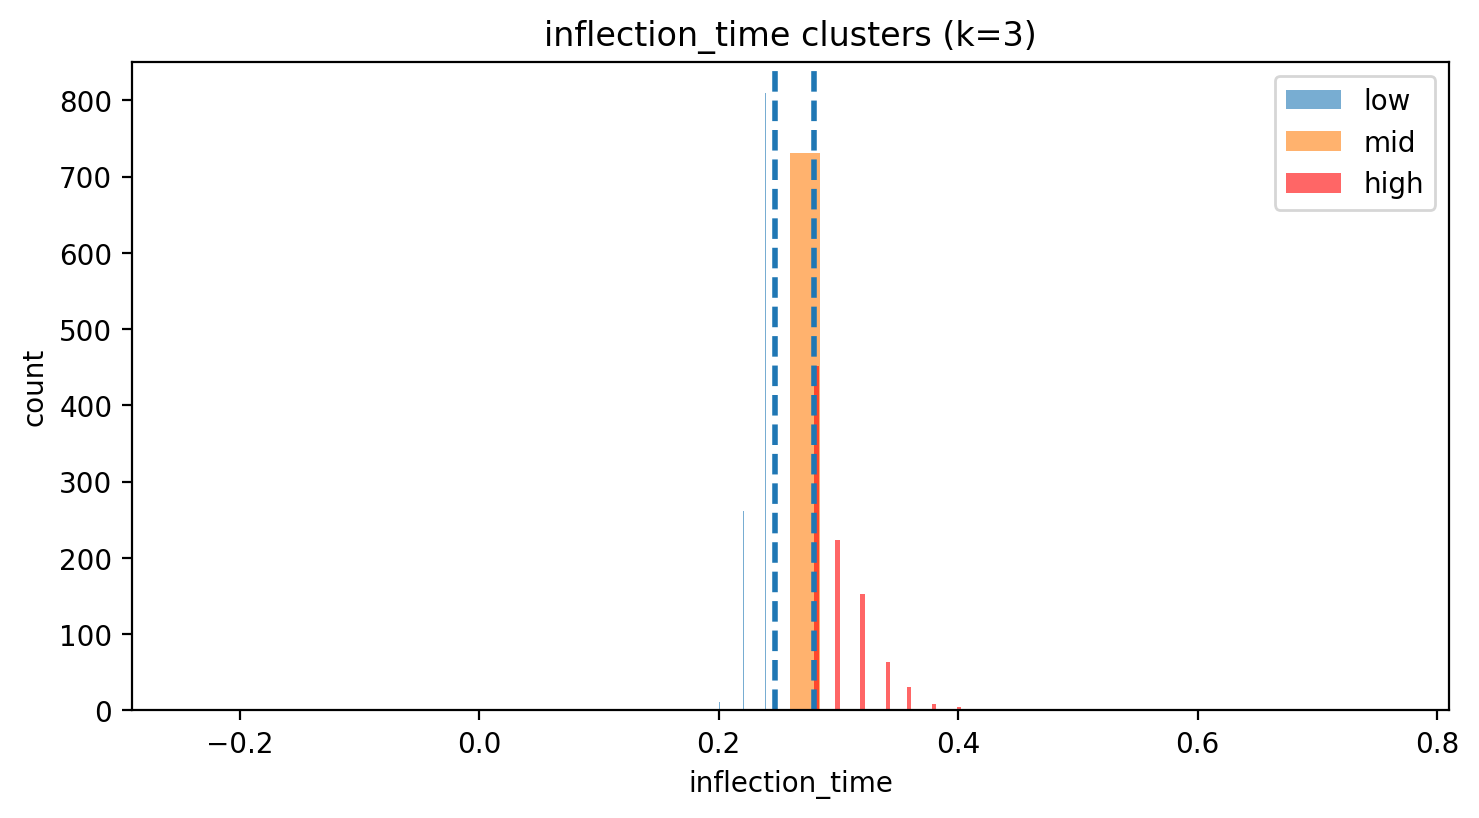

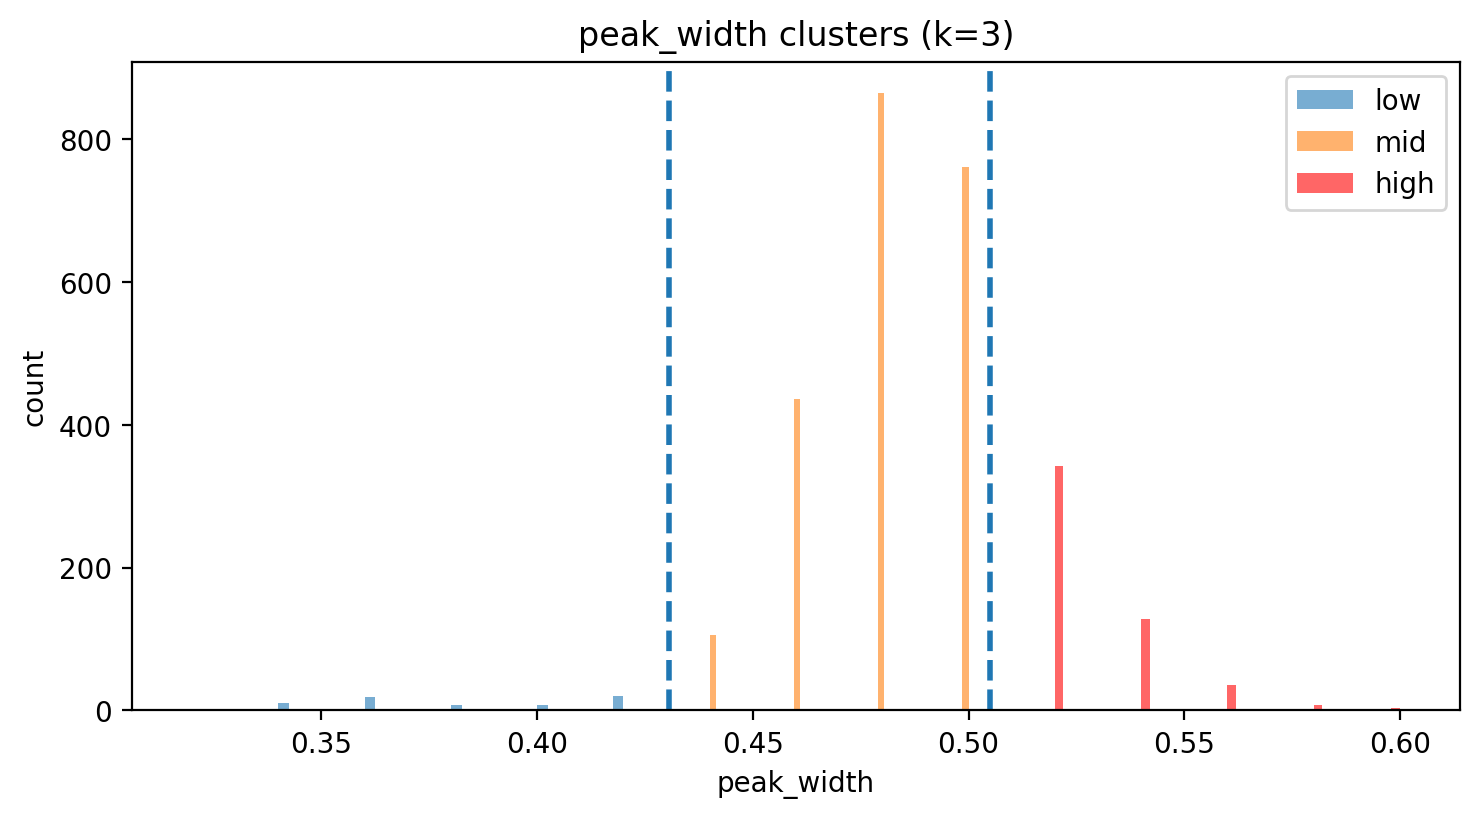

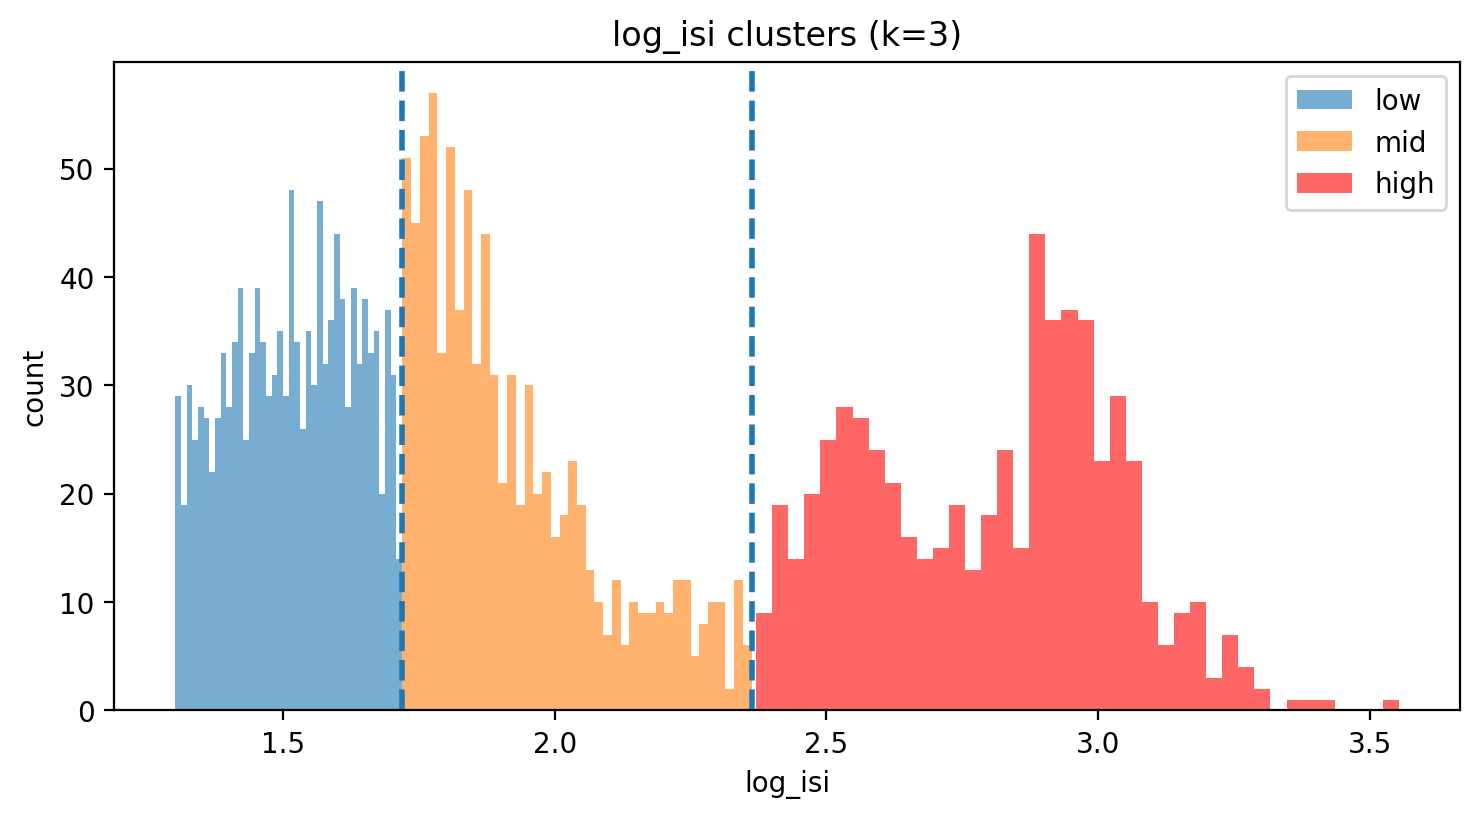

In [15]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features,
    max_k=25,
    suffix="_cluster",
    plot_each=True  # set True if you want a quick plot per clustered feature
)







In [16]:
df_features_clust

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id,inflection_time_cluster,peak_width_cluster,log_isi_cluster
4,5.339702,0.24,11.083944,282.080292,0.34,100.083379,0.000005,-11.844059,2.035142,47733,9.542041e+02,0,low,low,mid
28,8.355144,0.24,16.078914,300.450517,0.34,104.928247,0.000009,-13.335006,1.866670,197594,3.949993e+03,1,low,low,mid
29,5.820529,0.24,7.714819,278.730264,0.36,97.651217,0.000045,-12.320808,1.979978,201274,4.023558e+03,2,low,low,mid
45,8.137654,0.24,10.402733,282.025356,0.32,108.023199,0.000017,-16.620654,1.613211,272002,5.437442e+03,3,low,low,low
52,7.255401,0.24,16.356073,277.622851,0.32,95.527065,0.000022,-17.887700,1.633665,317683,6.350626e+03,4,low,low,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4877,5.857148,0.36,13.602138,238.235210,0.54,28.708466,9.582535,-11.783276,1.331827,53874323,1.076972e+06,2746,high,high,low
4879,4.093794,0.34,15.098414,231.180390,0.52,31.077915,9.754634,-22.804262,1.530248,53878359,1.077053e+06,2747,high,high,low
4880,5.954785,0.34,23.033010,239.707314,0.54,27.432366,10.000000,-7.741266,3.212635,53880055,1.077086e+06,2748,high,high,high
4883,4.138010,0.34,11.843785,236.465663,0.52,27.505821,10.000000,-15.762146,1.481235,53969332,1.078871e+06,2749,high,high,low
